In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(color_codes=True)

# Dataset :
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**About the Dataset:**  
The IBM Telco Customer Churn dataset contains information about a telecom company's customers.  
The goal is to predict whether a customer will churn (leave the service) based on features like contract type, monthly charges, tenure, internet service, and payment method.

**Target Column:** `Churn` — Yes (1) / No (0)

In [4]:

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Exploratory Data Analysis

In [5]:
# Shape and basic info
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [6]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


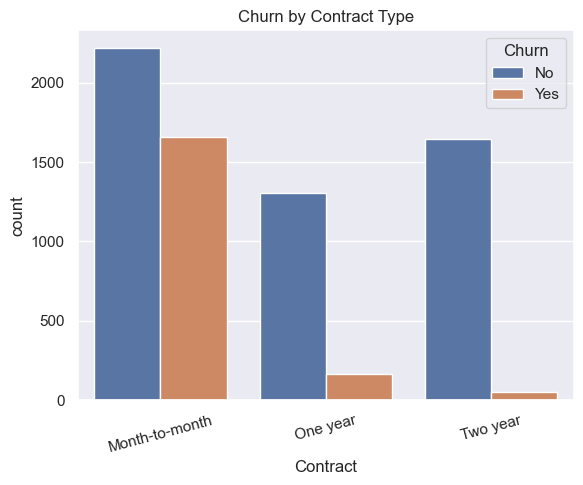

In [7]:
# Churn distribution
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

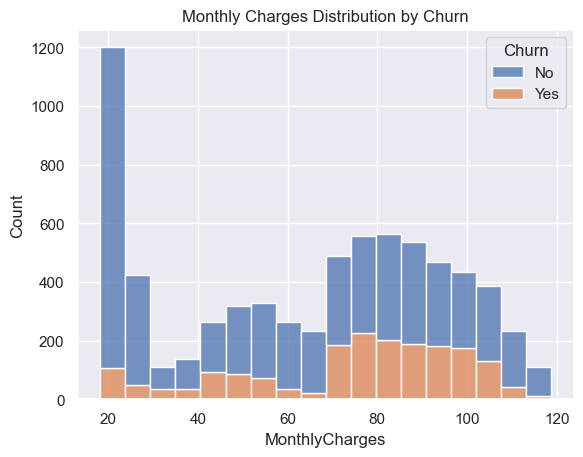

In [8]:
# Monthly Charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack')
plt.title('Monthly Charges Distribution by Churn')
plt.show()

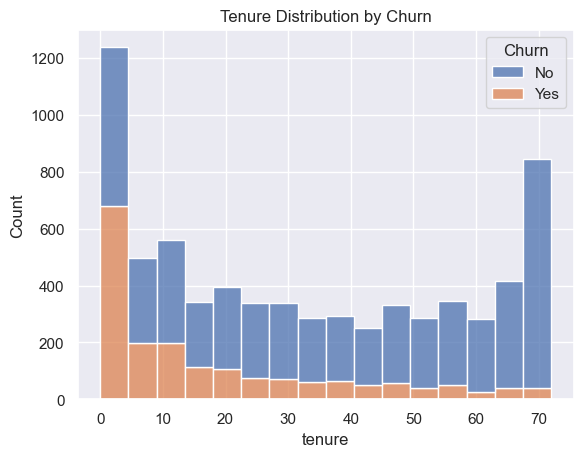

In [9]:
# Tenure distribution 
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.title('Tenure Distribution by Churn')
plt.show()

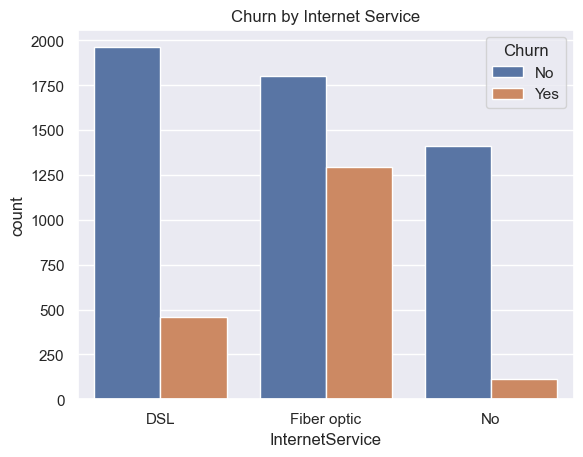

In [10]:
# Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

# Data Preprocessing

In [11]:
# Check null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
# TotalCharges has spaces instead of NaN — fix it
df_copy = df.copy(deep=True)
df_copy['TotalCharges'] = pd.to_numeric(df_copy['TotalCharges'], errors='coerce')

# Showing the Count of NANs after conversion
print(df_copy.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [13]:
# Fill NaN TotalCharges with median
df_copy['TotalCharges'].fillna(df_copy['TotalCharges'].median(), inplace=True)

# Drop customerID — not useful for prediction
df_copy.drop('customerID', axis=1, inplace=True)

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_copy[col] = df_copy[col].map({'Yes': 1, 'No': 0})

# Encode gender
df_copy['gender'] = df_copy['gender'].map({'Male': 1, 'Female': 0})

# Replace Label Encoding with One-Hot Encoding
df_copy = pd.get_dummies(df_copy, drop_first=True)

print("Encoding complete. Shape:", df_copy.shape)
df_copy.head()

Encoding complete. Shape: (7043, 31)


C:\Users\shish\AppData\Local\Temp\ipykernel_20452\3507541570.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['TotalCharges'].fillna(df_copy['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


# Check if the class label is balanced or not

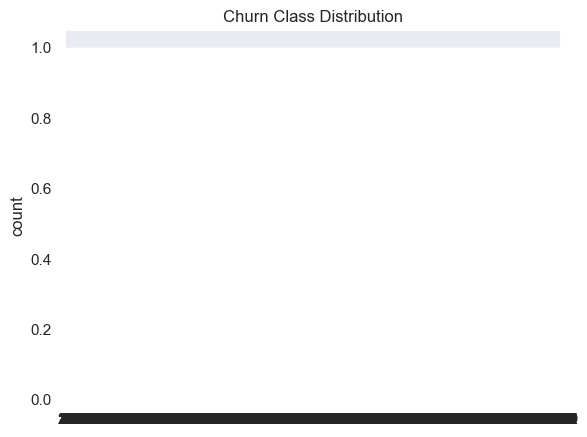

Churn
0    5174
1    1869
Name: count, dtype: int64


In [14]:
sns.countplot(df_copy['Churn'])
plt.title('Churn Class Distribution')
plt.show()
print(df_copy.Churn.value_counts())

# Do Oversampling Minority Class to Balance the class label

In [15]:
from sklearn.utils import resample

majority = df_copy[df_copy['Churn'] == 0]
minority = df_copy[df_copy['Churn'] == 1]

minority_updated = resample(minority, n_samples=len(majority), random_state=0)
df2 = pd.concat([minority_updated, majority])

print("After oversampling:")
print(df2.Churn.value_counts())

After oversampling:
Churn
1    5174
0    5174
Name: count, dtype: int64


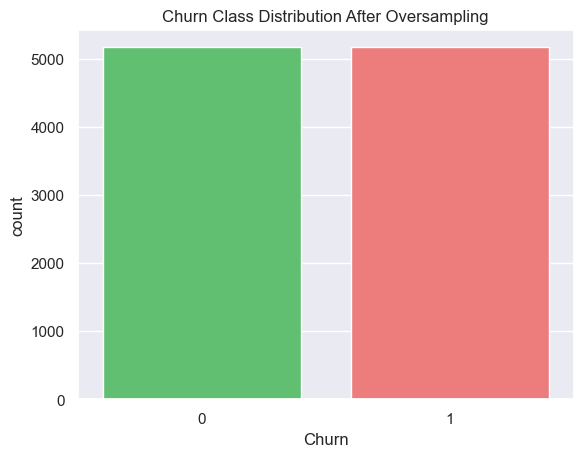

Churn
1    5174
0    5174
Name: count, dtype: int64


In [16]:
sns.countplot(data=df2, x='Churn', hue='Churn', palette=['#51cf66', '#ff6b6b'], legend=False)
plt.title('Churn Class Distribution After Oversampling')
plt.show()
print(df2.Churn.value_counts())

# Check the Outlier using Boxplot

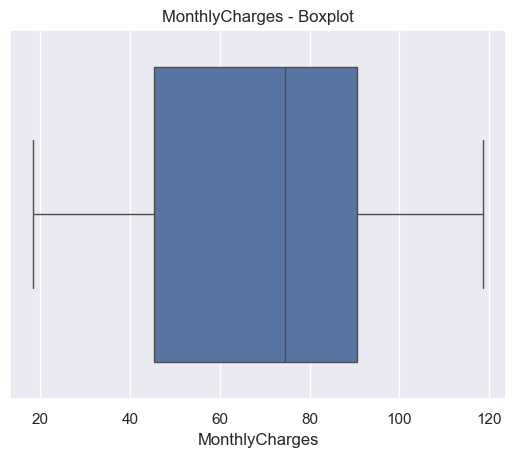

In [17]:
sns.boxplot(x=df2['MonthlyCharges'])
plt.title('MonthlyCharges - Boxplot')
plt.show()

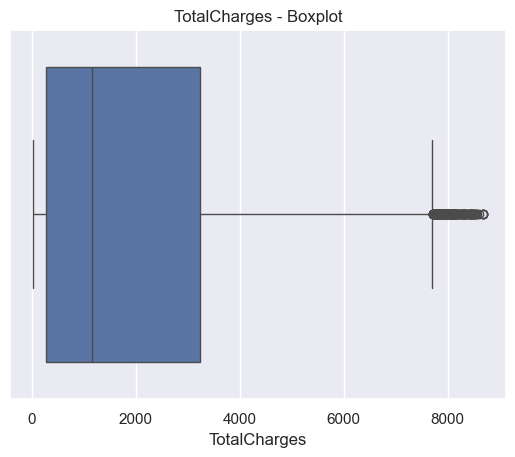

In [18]:
sns.boxplot(x=df2['TotalCharges'])
plt.title('TotalCharges - Boxplot')
plt.show()

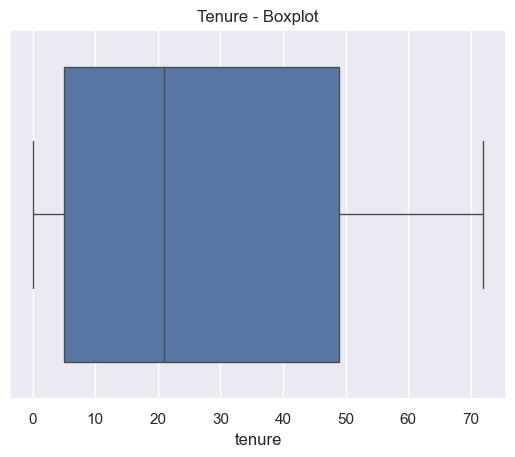

In [19]:
sns.boxplot(x=df2['tenure'])
plt.title('Tenure - Boxplot')
plt.show()

# Remove Outlier using Z-Score

In [20]:
import scipy.stats as stats

numeric_df = df2.select_dtypes(include=[np.number])
z = np.abs(stats.zscore(numeric_df, nan_policy='omit'))
z = np.nan_to_num(z, nan=0.0)

data_clean = df2[(z < 3).all(axis=1)]
print("Shape after outlier removal:", data_clean.shape)

Shape after outlier removal: (9371, 31)


# Heatmap Data Correlation

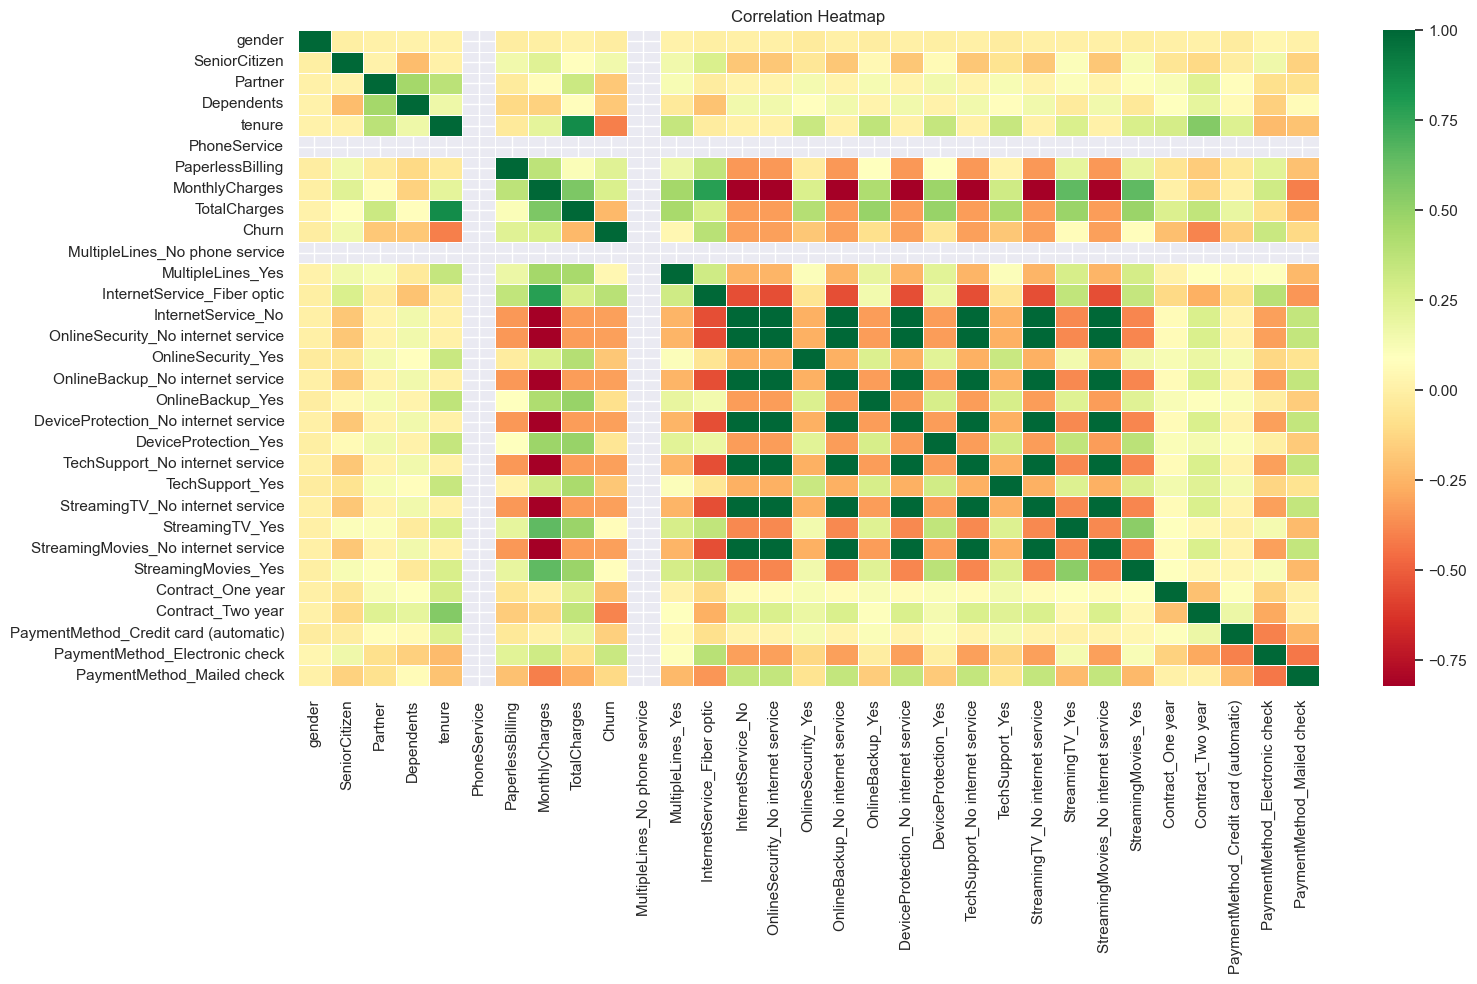

In [21]:
plt.figure(figsize=(16, 10))
sns.heatmap(data_clean.corr(), fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [22]:
# Print top correlated features with Churn
print("Top features correlated with Churn:")
print(data_clean.corr()['Churn'].drop('Churn').sort_values(ascending=False))

Top features correlated with Churn:
InternetService_Fiber optic              0.381900
PaymentMethod_Electronic check           0.327969
MonthlyCharges                           0.262362
PaperlessBilling                         0.231845
SeniorCitizen                            0.158101
StreamingMovies_Yes                      0.076804
StreamingTV_Yes                          0.073759
MultipleLines_Yes                        0.045476
gender                                  -0.013980
DeviceProtection_Yes                    -0.058558
OnlineBackup_Yes                        -0.083102
PaymentMethod_Mailed check              -0.111330
PaymentMethod_Credit card (automatic)   -0.151971
Partner                                 -0.175505
Dependents                              -0.179880
TechSupport_Yes                         -0.182990
OnlineSecurity_Yes                      -0.185102
Contract_One year                       -0.215456
TotalCharges                            -0.233586
InternetServic

# Machine Learning Model Building

In [23]:
X = data_clean.drop('Churn', axis=1)
y = data_clean['Churn']

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Split first (GOOD )
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Apply SMOTE only on training data (CORRECT )
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (7544, 30)
Test size:  (1875, 30)


c:\Users\shish\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\shish\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\shish\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shish\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

# Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=0)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score   :', recall_score(y_test, y_pred))

Accuracy Score : 77.87 %
F-1 Score      : 0.7885888945491595
Precision Score: 0.7588235294117647
Recall Score   : 0.8207847295864263


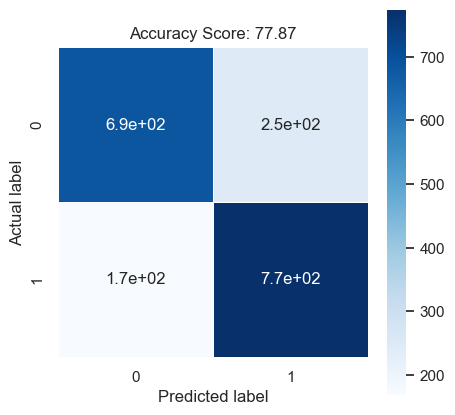

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(lr.score(X_test, y_test)*100, 2)))
plt.show()

# Adaboost Algorithm

In [26]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score   :', recall_score(y_test, y_pred))

Accuracy Score : 78.77 %
F-1 Score      : 0.7961065573770492
Precision Score: 0.7700693756194251
Recall Score   : 0.823966065747614


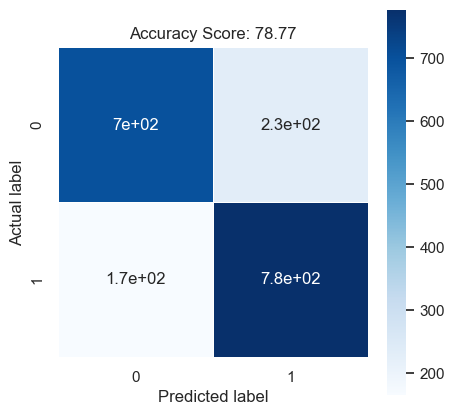

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(ada.score(X_test, y_test)*100, 2)))
plt.show()

# K Nearest Neighbour

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score   :', recall_score(y_test, y_pred))

Accuracy Score : 77.07 %
F-1 Score      : 0.7862823061630219
Precision Score: 0.7399438727782974
Recall Score   : 0.83881230116649


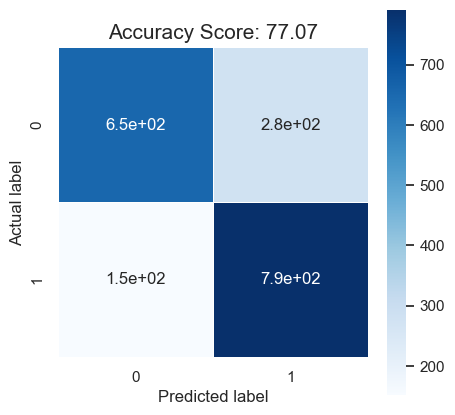

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(knn.score(X_test, y_test)*100, 2)), size=15)
plt.show()

# Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters you want to test
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the model and the Grid Search
rfc_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rfc_base, param_grid=rf_params,cv=3, n_jobs=-1, scoring='accuracy', verbose=2)

# Fit the Grid Search on the SMOTE training data
grid_search.fit(X_train, y_train)

# Get the best model
rfc_best = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Evaluate the tuned model
y_pred_rf = rfc_best.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred_rf))
print('Precision Score:', precision_score(y_test, y_pred_rf))
print('Recall Score   :', recall_score(y_test, y_pred_rf))

# Use rfc_best for your pickle file export later

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy Score : 90.24 %
F-1 Score      : 0.9079939668174962
Precision Score: 0.8632887189292543
Recall Score   : 0.9575821845174973


In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Initialize and train the SVC model
# Note: SVMs are sensitive to unscaled data. You may want to scale X_train and X_test using StandardScaler if you haven't.
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train, y_train)

# Predict on test set
y_pred_svc = svc.predict(X_test)

# Evaluate the model
print("SVC Accuracy Score :", round(accuracy_score(y_test, y_pred_svc)*100, 2), "%")
print('SVC F-1 Score      :', f1_score(y_test, y_pred_svc))
print('SVC Precision Score:', precision_score(y_test, y_pred_svc))
print('SVC Recall Score   :', recall_score(y_test, y_pred_svc))

SVC Accuracy Score : 66.08 %
SVC F-1 Score      : 0.6470588235294118
SVC Precision Score: 0.6786961583236322
SVC Recall Score   : 0.6182396606574762


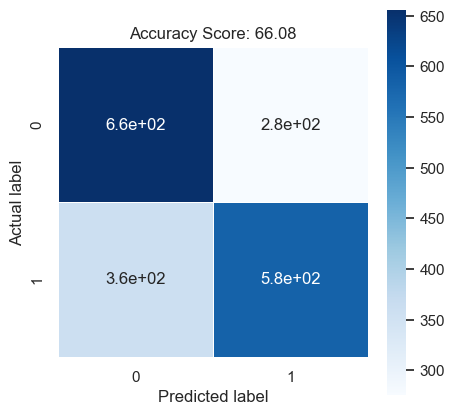

In [32]:
cm = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(svc.score(X_test, y_test)*100, 2)))
plt.show()

In [33]:
%pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy Score :", round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print('XGBoost F-1 Score      :', f1_score(y_test, y_pred_xgb))
print('XGBoost Precision Score:', precision_score(y_test, y_pred_xgb))
print('XGBoost Recall Score   :', recall_score(y_test, y_pred_xgb))

Note: you may need to restart the kernel to use updated packages.
XGBoost Accuracy Score : 87.31 %
XGBoost F-1 Score      : 0.8795546558704453
XGBoost Precision Score: 0.8412391093901258
XGBoost Recall Score   : 0.9215270413573701


c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:21:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


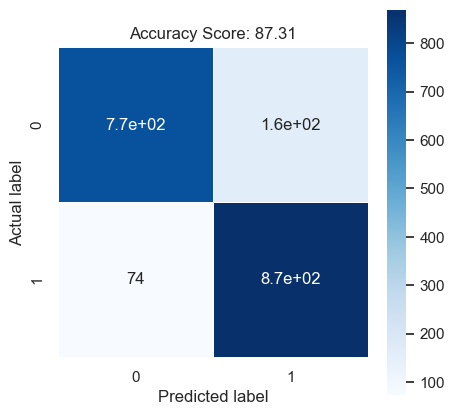

In [34]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(xgb.score(X_test, y_test)*100, 2)))
plt.show()

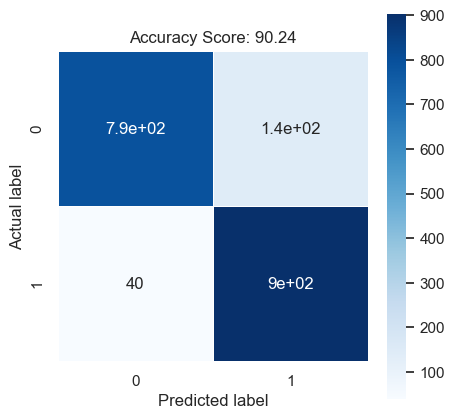

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(rfc_best.score(X_test, y_test)*100, 2)))
plt.show()

# Model Accuracy Comparison

                 Model  Accuracy (%)
0        Random Forest         90.24
1              XGBoost         87.31
2             AdaBoost         78.77
3  Logistic Regression         77.87
4                  KNN         77.07
5                  SVC         66.08


C:\Users\shish\AppData\Local\Temp\ipykernel_20452\171220087.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='Accuracy (%)', palette='Blues_d')


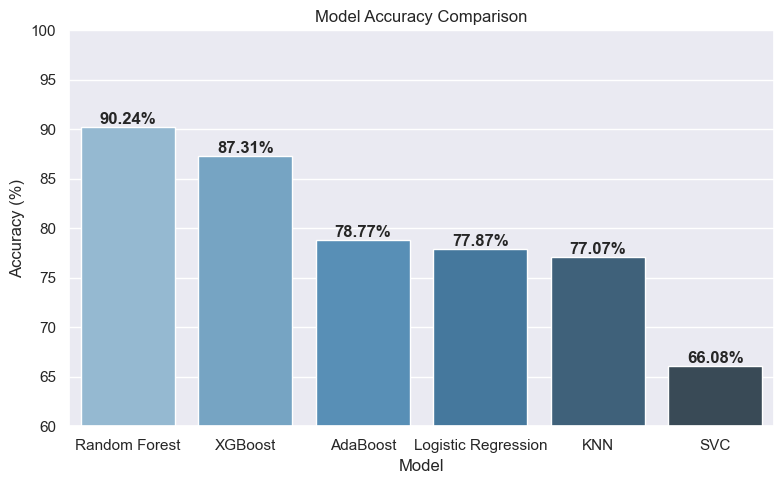

In [36]:
models     = ['Logistic Regression', 'AdaBoost', 'KNN', 'Random Forest', 'SVC', 'XGBoost']
classifiers = [lr, ada, knn, rfc_best, svc, xgb]
accuracies  = [round(clf.score(X_test, y_test)*100, 2) for clf in classifiers]

comparison_df = pd.DataFrame({'Model': models, 'Accuracy (%)': accuracies})
comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='Model', y='Accuracy (%)', palette='Blues_d')
plt.title('Model Accuracy Comparison')
plt.ylim(60, 100)
for i, v in enumerate(comparison_df['Accuracy (%)']):
    plt.text(i, v + 0.3, str(v) + '%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


SVC WITH FEATURE SCALING

SVC Performance (With Scaling):
Accuracy: 0.7883
Precision: 0.7630
Recall: 0.8399
F1-Score: 0.7996

------------------------------------------------------------
COMPARISON: SVC Without vs With Scaling
------------------------------------------------------------
   Metric  Without Scaling  With Scaling
 Accuracy         0.660800      0.788267
Precision         0.678696      0.763006
   Recall         0.618240      0.839873
 F1-Score         0.647059      0.799596


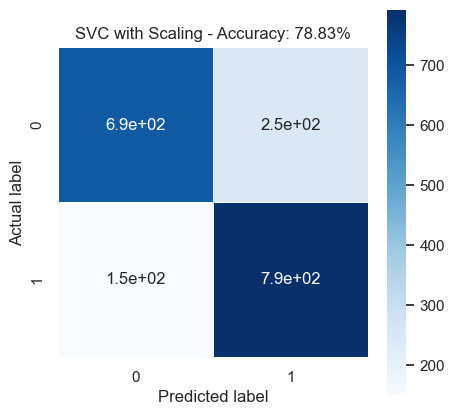

In [37]:
# SVC with Feature Scaling (SVMs are sensitive to scale)
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 60)
print("SVC WITH FEATURE SCALING")
print("=" * 60)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVC on scaled data
svc_scaled = SVC(kernel='rbf', random_state=42, probability=True)
svc_scaled.fit(X_train_scaled, y_train)

y_pred_svc_scaled = svc_scaled.predict(X_test_scaled)

print("\nSVC Performance (With Scaling):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_scaled):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svc_scaled):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svc_scaled):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svc_scaled):.4f}")

print("\n" + "-" * 60)
print("COMPARISON: SVC Without vs With Scaling")
print("-" * 60)
svc_comparison = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Without Scaling': [
        accuracy_score(y_test, y_pred_svc),
        precision_score(y_test, y_pred_svc),
        recall_score(y_test, y_pred_svc),
        f1_score(y_test, y_pred_svc)
    ],
    'With Scaling': [
        accuracy_score(y_test, y_pred_svc_scaled),
        precision_score(y_test, y_pred_svc_scaled),
        recall_score(y_test, y_pred_svc_scaled),
        f1_score(y_test, y_pred_svc_scaled)
    ]
}

svc_comparison_df = pd.DataFrame(svc_comparison)
print(svc_comparison_df.to_string(index=False))

# Visualize confusion matrix for scaled SVC
cm_svc_scaled = confusion_matrix(y_test, y_pred_svc_scaled)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm_svc_scaled, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title(f'SVC with Scaling - Accuracy: {round(svc_scaled.score(X_test_scaled, y_test)*100, 2)}%')
plt.show()


## SVC with Feature Scaling (Improved)

In [38]:
# Try Random Forest with class weight balancing
print("\n" + "=" * 60)
print("RANDOM FOREST WITH CLASS WEIGHTS")
print("=" * 60)

rfc_weighted = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rfc_weighted.fit(X_train, y_train)
y_pred_weighted = rfc_weighted.predict(X_test)

print("\nClass-Weighted Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_weighted):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_weighted):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_weighted):.4f}")

# Compare with original rfc_best
print("\n" + "-" * 60)
print("COMPARISON: Original vs Class-Weighted")
print("-" * 60)
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Original RF': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ],
    'Class-Weighted RF': [
        accuracy_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_weighted)
    ]
}

comparison_df_weights = pd.DataFrame(comparison_data)
print(comparison_df_weights.to_string(index=False))



RANDOM FOREST WITH CLASS WEIGHTS

Class-Weighted Random Forest Performance:
Accuracy: 0.8715
Precision: 0.8401
Recall: 0.9194
F1-Score: 0.8780

------------------------------------------------------------
COMPARISON: Original vs Class-Weighted
------------------------------------------------------------
   Metric  Original RF  Class-Weighted RF
 Accuracy     0.902400           0.871467
Precision     0.863289           0.840116
   Recall     0.957582           0.919406
 F1-Score     0.907994           0.877975


## Random Forest with Class Weights (Alternative Approach)

In [39]:
# Detailed Classification Report for best model
print("\n" + "=" * 60)
print("RANDOM FOREST - DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

print("\n" + "=" * 60)
print("MODEL INTERPRETATION")
print("=" * 60)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"True Negatives (Correctly predicted no churn): {tn}")
print(f"False Positives (Predicted churn, but didn't): {fp}")
print(f"False Negatives (Predicted no churn, but did): {fn}")
print(f"True Positives (Correctly predicted churn): {tp}")
print(f"\nRecall (catch actual churners): {tp / (tp + fn):.4f}")
print(f"Precision (avoid false alarms): {tp / (tp + fp):.4f}")
print(f"\nBusiness Impact:")
print(f"- Out of {tn + fn} actual 'No Churn' customers, we correctly identified {tn}")
print(f"- Out of {tp + fn} actual churners, we correctly caught {tp}")



RANDOM FOREST - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.95      0.85      0.90       932
       Churn       0.86      0.96      0.91       943

    accuracy                           0.90      1875
   macro avg       0.91      0.90      0.90      1875
weighted avg       0.91      0.90      0.90      1875


MODEL INTERPRETATION
True Negatives (Correctly predicted no churn): 789
False Positives (Predicted churn, but didn't): 143
False Negatives (Predicted no churn, but did): 40
True Positives (Correctly predicted churn): 903

Recall (catch actual churners): 0.9576
Precision (avoid false alarms): 0.8633

Business Impact:
- Out of 829 actual 'No Churn' customers, we correctly identified 789
- Out of 943 actual churners, we correctly caught 903


## Detailed Classification Report


Top 15 Most Important Features:
                       Feature  Importance
                  TotalCharges    0.178845
                        tenure    0.167519
                MonthlyCharges    0.164169
             Contract_Two year    0.053191
   InternetService_Fiber optic    0.051180
PaymentMethod_Electronic check    0.030980
            OnlineSecurity_Yes    0.027129
             Contract_One year    0.025565
               TechSupport_Yes    0.025034
                        gender    0.024924
              PaperlessBilling    0.024790
                       Partner    0.021663
              OnlineBackup_Yes    0.020222
             MultipleLines_Yes    0.019676
                    Dependents    0.019488


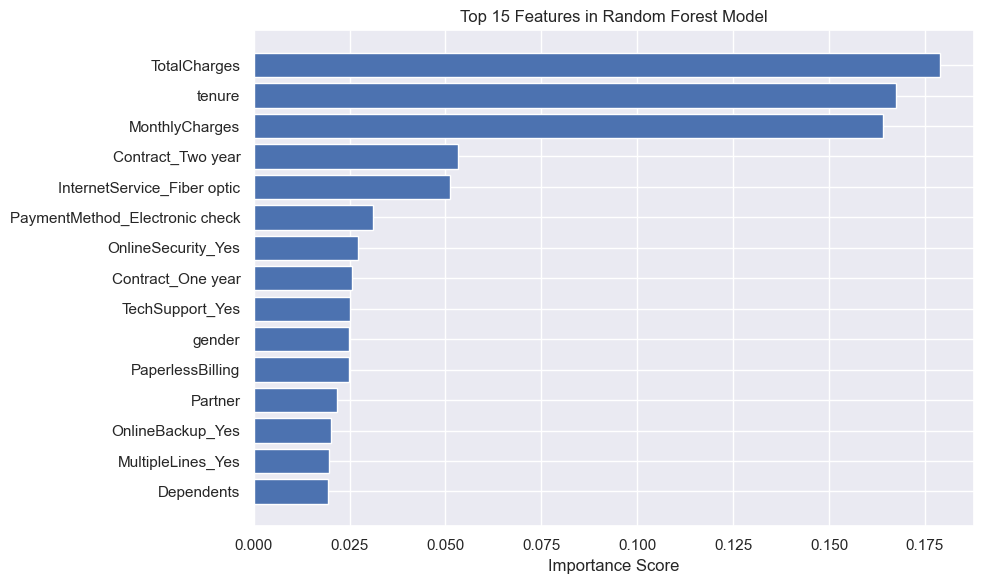


Number of features needed to explain 80% of importance: 13
Out of total features: 30


In [40]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rfc_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Visualize Top 15 Features
plt.figure(figsize=(10, 6))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values)
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 15 Features in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Features contributing to 80% of importance
cumsum = feature_importance['Importance'].cumsum()
n_features_80 = (cumsum <= 0.8).sum() + 1
print(f"\nNumber of features needed to explain 80% of importance: {n_features_80}")
print(f"Out of total features: {len(X.columns)}")


## Feature Importance Analysis

In [41]:
# Cross-Validation Analysis
from sklearn.model_selection import cross_val_score

print("=" * 60)
print("CROSS-VALIDATION ANALYSIS")
print("=" * 60)

# Perform 5-fold cross-validation on Random Forest
cv_scores = cross_val_score(rfc_best, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nRandom Forest - 5-Fold Cross-Validation Scores:")
print(f"Individual Fold Scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: {cv_scores.mean():.4f} (+/- {1.96 * cv_scores.std():.4f})")

# Compare with other models
print("\n" + "=" * 60)
print("CROSS-VALIDATION COMPARISON")
print("=" * 60)
models_to_validate = {
    'Logistic Regression': lr,
    'AdaBoost': ada,
    'KNN': knn,
    'SVC': svc,
    'XGBoost': xgb
}

cv_results = {}
for model_name, model in models_to_validate.items():
    cv_scores_model = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[model_name] = cv_scores_model.mean()
    print(f"{model_name:25} Mean CV Accuracy: {cv_scores_model.mean():.4f}")


CROSS-VALIDATION ANALYSIS

Random Forest - 5-Fold Cross-Validation Scores:
Individual Fold Scores: ['0.8748', '0.8854', '0.9026', '0.8754', '0.8879']
Mean Accuracy: 0.8852
Std Dev: 0.0101
95% Confidence Interval: 0.8852 (+/- 0.0199)

CROSS-VALIDATION COMPARISON


c:\Users\shish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\shish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression       Mean CV Accuracy: 0.7675
AdaBoost                  Mean CV Accuracy: 0.7663
KNN                       Mean CV Accuracy: 0.7521
SVC                       Mean CV Accuracy: 0.6463


c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:21:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:21:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:21:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:21:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

XGBoost                   Mean CV Accuracy: 0.8522


c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:21:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Model Validation & Analysis

# Export the Best Model
Let's export the Random Forest model and the column names so our Flask app can process new incoming data accurately.

In [42]:
import pickle

# Ensure rfc_best exists (if the Random Forest training cell was not run)
if 'rfc_best' not in globals():
    from sklearn.ensemble import RandomForestClassifier
    rfc_best = RandomForestClassifier(n_estimators=100, random_state=0)
    rfc_best.fit(X_train, y_train)

# Save the Random Forest Model
with open('model.pkl', 'wb') as f:
    pickle.dump(rfc_best, f)

# Save feature columns to match Flask app inputs
feature_columns = list(X.columns) if 'X' in globals() else list(X_train.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Model and columns saved successfully!")

Model and columns saved successfully!
